In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r'C:\Users\anura\Downloads\WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(df.shape)
print(df['Attrition'].value_counts())
df.head()

(1470, 35)
Attrition
No     1233
Yes     237
Name: count, dtype: int64


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
# Cell 2 — Basic Exploration
print("Missing values:", df.isnull().sum().sum())
print("\nAttrition Rate:", round(df['Attrition'].value_counts(normalize=True)['Yes'] * 100, 2), "%")

# Drop columns that add no value
df = df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1)
print("\nNew shape:", df.shape)
print("\nData types:\n", df.dtypes.value_counts())

Missing values: 0

Attrition Rate: 16.12 %

New shape: (1470, 31)

Data types:
 int64     23
object     8
Name: count, dtype: int64


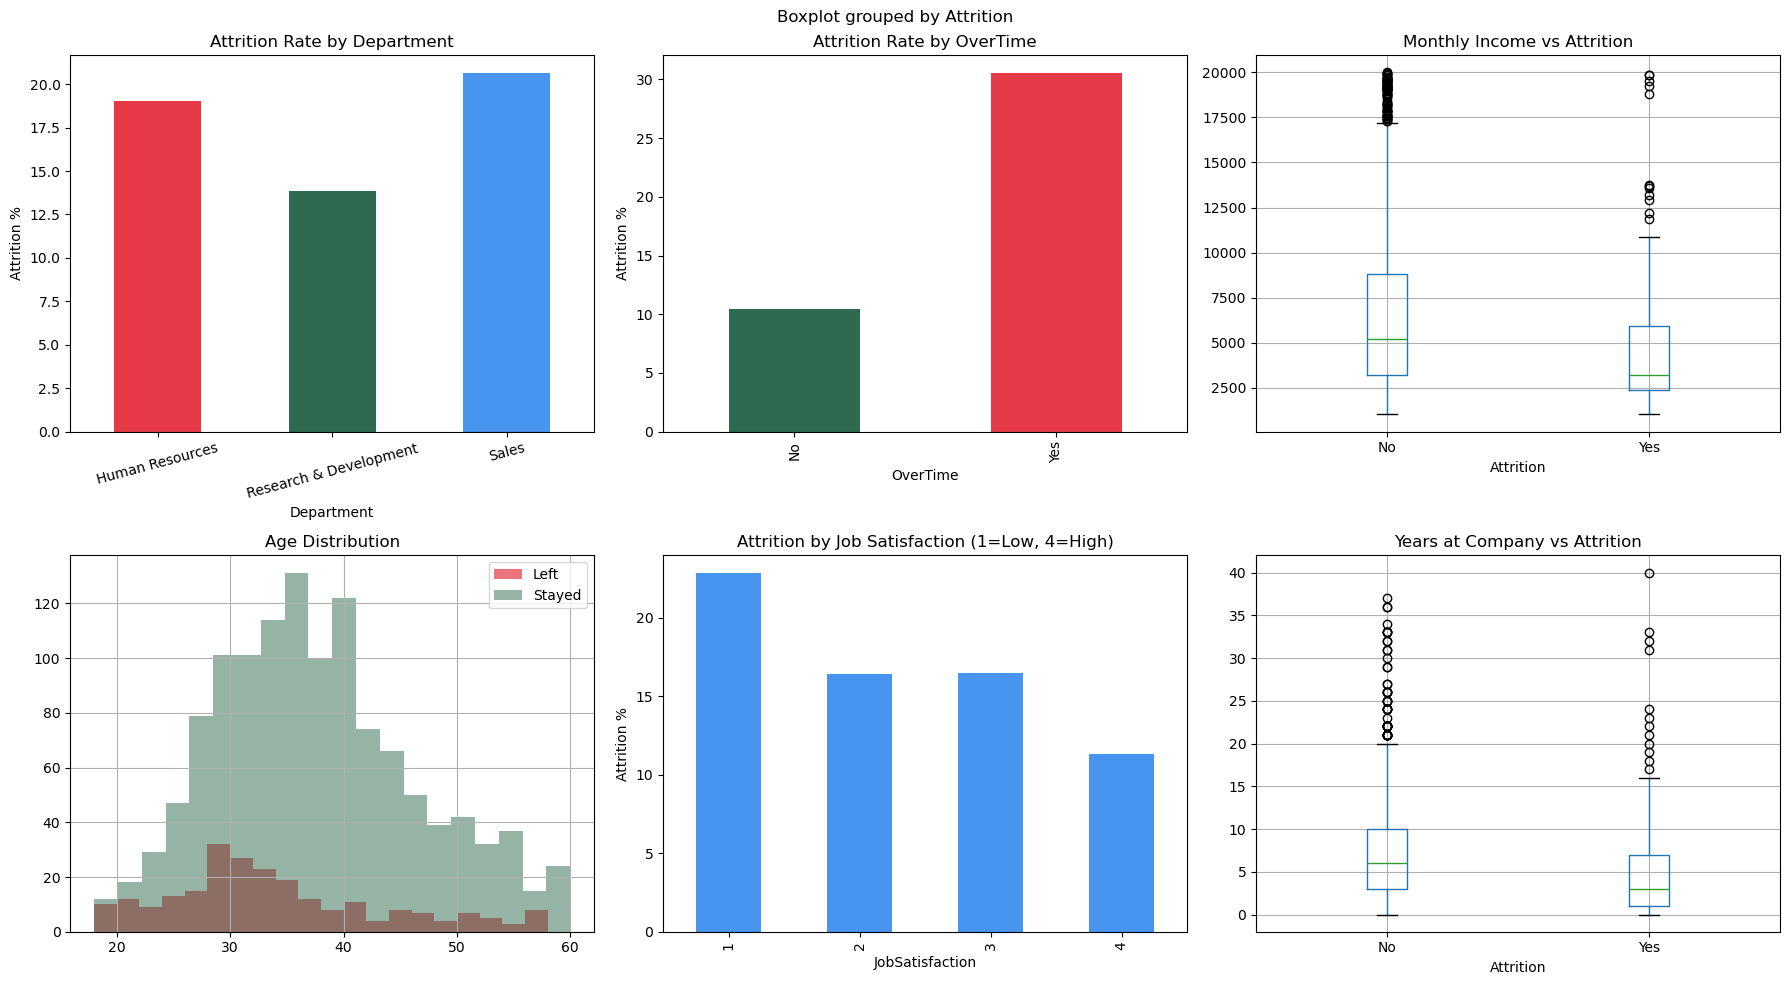

In [6]:
# Cell 3 — EDA Visualisations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('HR Attrition Analysis', fontsize=16, fontweight='bold')

# 1. Attrition by Department
df.groupby('Department')['Attrition'].apply(
    lambda x: (x=='Yes').sum()/len(x)*100
).plot(kind='bar', ax=axes[0,0], color=['#e63946','#2d6a4f','#4895ef'])
axes[0,0].set_title('Attrition Rate by Department')
axes[0,0].set_ylabel('Attrition %')
axes[0,0].tick_params(axis='x', rotation=15)

# 2. Attrition by OverTime
df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x=='Yes').sum()/len(x)*100
).plot(kind='bar', ax=axes[0,1], color=['#2d6a4f','#e63946'])
axes[0,1].set_title('Attrition Rate by OverTime')
axes[0,1].set_ylabel('Attrition %')

# 3. Monthly Income Distribution
df.boxplot(column='MonthlyIncome', by='Attrition', ax=axes[0,2])
axes[0,2].set_title('Monthly Income vs Attrition')
axes[0,2].set_xlabel('Attrition')

# 4. Age Distribution
df[df['Attrition']=='Yes']['Age'].hist(ax=axes[1,0], bins=20, color='#e63946', alpha=0.7, label='Left')
df[df['Attrition']=='No']['Age'].hist(ax=axes[1,0], bins=20, color='#2d6a4f', alpha=0.5, label='Stayed')
axes[1,0].set_title('Age Distribution')
axes[1,0].legend()

# 5. Job Satisfaction
df.groupby('JobSatisfaction')['Attrition'].apply(
    lambda x: (x=='Yes').sum()/len(x)*100
).plot(kind='bar', ax=axes[1,1], color='#4895ef')
axes[1,1].set_title('Attrition by Job Satisfaction (1=Low, 4=High)')
axes[1,1].set_ylabel('Attrition %')

# 6. Years at Company
df.boxplot(column='YearsAtCompany', by='Attrition', ax=axes[1,2])
axes[1,2].set_title('Years at Company vs Attrition')
axes[1,2].set_xlabel('Attrition')

plt.tight_layout()
plt.show()

In [7]:
# Cell 4 — Preprocessing
from sklearn.preprocessing import LabelEncoder

# Encode target variable
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Encode all other text columns
le = LabelEncoder()
text_columns = df.select_dtypes(include='object').columns
for col in text_columns:
    df[col] = le.fit_transform(df[col])

print("All columns are now numeric:")
print(df.dtypes.value_counts())
print("\nAttrition value counts:", df['Attrition'].value_counts().to_dict()) 

All columns are now numeric:
int64    31
Name: count, dtype: int64

Attrition value counts: {0: 1233, 1: 237}


In [8]:
# Cell 5 — Train/Test Split + Handle Imbalance
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Separate features (X) and target (y)
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE to fix class imbalance
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_sm.value_counts().to_dict())
print("\nTest set shape:", X_test.shape)

Before SMOTE: {0: 986, 1: 190}
After SMOTE: {0: 986, 1: 986}

Test set shape: (294, 30)


In [9]:
# Cell 6 — Train Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import xgboost as xgb

# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=10, 
                             random_state=42, class_weight='balanced')
rf.fit(X_train_sm, y_train_sm)
rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:,1]

# XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=200, max_depth=6, 
                                learning_rate=0.05, random_state=42,
                                eval_metric='logloss')
xgb_model.fit(X_train_sm, y_train_sm)
xgb_preds = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:,1]

# Results
print("=" * 40)
print("RANDOM FOREST RESULTS")
print("=" * 40)
print(classification_report(y_test, rf_preds))
print("ROC AUC:", round(roc_auc_score(y_test, rf_proba), 3))

print("=" * 40)
print("XGBOOST RESULTS")
print("=" * 40)
print(classification_report(y_test, xgb_preds))
print("ROC AUC:", round(roc_auc_score(y_test, xgb_proba), 3))

RANDOM FOREST RESULTS
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       247
           1       0.38      0.38      0.38        47

    accuracy                           0.80       294
   macro avg       0.63      0.63      0.63       294
weighted avg       0.80      0.80      0.80       294

ROC AUC: 0.727
XGBOOST RESULTS
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       247
           1       0.41      0.36      0.39        47

    accuracy                           0.82       294
   macro avg       0.65      0.63      0.64       294
weighted avg       0.81      0.82      0.81       294

ROC AUC: 0.746


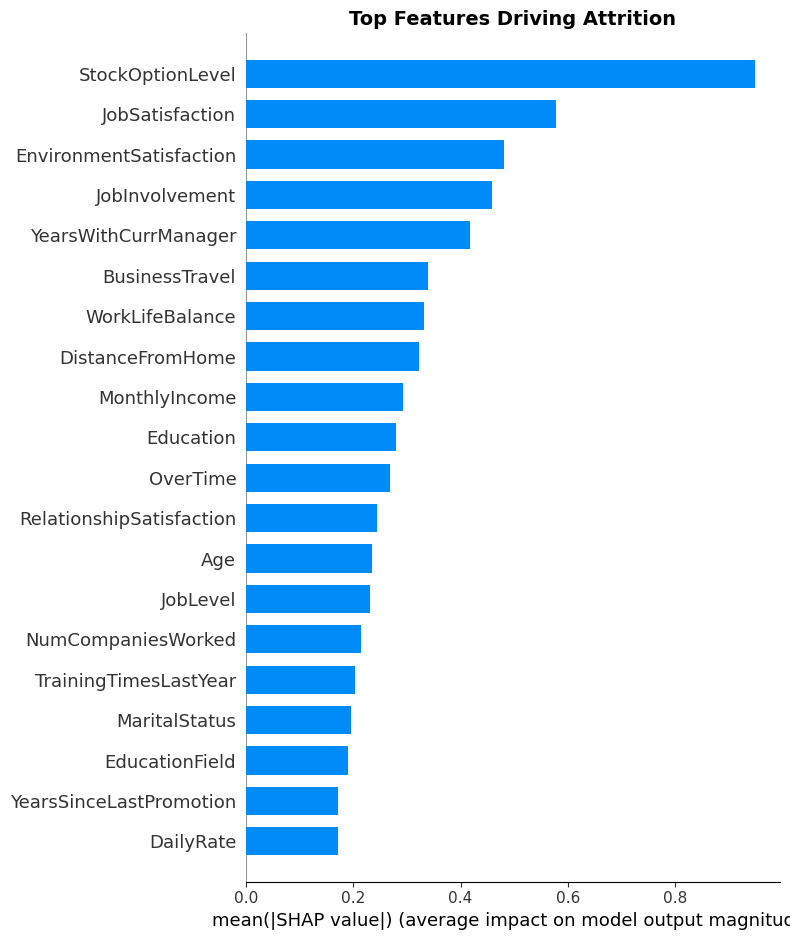

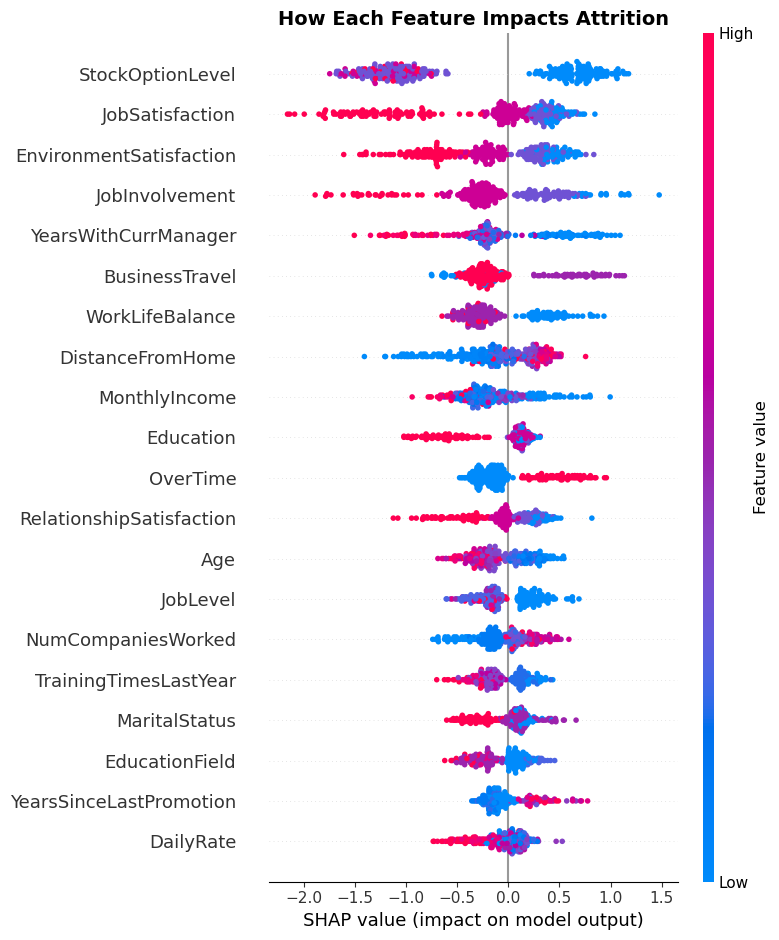

In [10]:
# Cell 7 — SHAP Analysis
import shap

# Create SHAP explainer using XGBoost (best model)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Plot 1 — Global Feature Importance
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", 
                  feature_names=X.columns, show=False)
plt.title('Top Features Driving Attrition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 2 — SHAP Dot Plot (direction of impact)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, 
                  feature_names=X.columns, show=False)
plt.title('How Each Feature Impacts Attrition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# Cell 8 — Risk Score for Every Employee
# Add attrition probability to original test set
X_test_copy = X_test.copy()
X_test_copy['Attrition_Actual'] = y_test.values
X_test_copy['Attrition_Risk_%'] = (xgb_proba * 100).round(1)
X_test_copy['Risk_Category'] = pd.cut(
    X_test_copy['Attrition_Risk_%'],
    bins=[0, 30, 60, 100],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# Summary
print("Risk Category Distribution:")
print(X_test_copy['Risk_Category'].value_counts())
print("\nTop 10 Highest Risk Employees:")
print(X_test_copy.sort_values('Attrition_Risk_%', ascending=False)
      [['Attrition_Risk_%', 'Risk_Category', 'Attrition_Actual']].head(10))

Risk Category Distribution:
Risk_Category
Low Risk       229
Medium Risk     34
High Risk       31
Name: count, dtype: int64

Top 10 Highest Risk Employees:
      Attrition_Risk_% Risk_Category  Attrition_Actual
1311         96.500000     High Risk                 0
744          96.400002     High Risk                 1
318          96.300003     High Risk                 0
1021         96.199997     High Risk                 1
688          96.199997     High Risk                 1
357          95.199997     High Risk                 1
911          94.900002     High Risk                 1
711          94.900002     High Risk                 1
762          93.699997     High Risk                 1
732          93.400002     High Risk                 1


In [12]:
# Cell 9 — What-If Simulator
def what_if_simulator(employee_index, changes):
    """
    Simulate how changing features affects an employee's attrition risk.
    employee_index: row number from X_test
    changes: dictionary of feature changes e.g. {'OverTime': 0, 'JobSatisfaction': 4}
    """
    # Get original employee
    original = X_test.iloc[employee_index].copy()
    original_risk = xgb_model.predict_proba([original])[0][1] * 100
    
    # Apply changes
    modified = original.copy()
    for feature, new_value in changes.items():
        modified[feature] = new_value
    new_risk = xgb_model.predict_proba([modified])[0][1] * 100
    
    print(f"Employee #{employee_index} — What-If Analysis")
    print("=" * 45)
    print(f"Original Attrition Risk:  {original_risk:.1f}%")
    print(f"Modified Attrition Risk:  {new_risk:.1f}%")
    print(f"Risk Change:              {new_risk - original_risk:+.1f}%")
    print("\nChanges Applied:")
    for feature, new_value in changes.items():
        print(f"  {feature}: {original[feature]} → {new_value}")

# Test 1: What if we remove overtime for a high risk employee?
what_if_simulator(0, {'OverTime': 0})

print("\n")

# Test 2: What if we improve job satisfaction AND give stock options?
what_if_simulator(0, {'JobSatisfaction': 4, 'StockOptionLevel': 2, 'OverTime': 0})

Employee #0 — What-If Analysis
Original Attrition Risk:  56.8%
Modified Attrition Risk:  56.8%
Risk Change:              +0.0%

Changes Applied:
  OverTime: 0 → 0


Employee #0 — What-If Analysis
Original Attrition Risk:  56.8%
Modified Attrition Risk:  25.3%
Risk Change:              -31.4%

Changes Applied:
  JobSatisfaction: 2 → 4
  StockOptionLevel: 1 → 2
  OverTime: 0 → 0


In [13]:
# Test on a genuinely high risk employee
# Find index of highest risk employee
highest_risk_idx = X_test_copy['Attrition_Risk_%'].idxmax()
pos = X_test.index.get_loc(highest_risk_idx)

# See their current situation
print("Highest risk employee features:")
print(X_test.iloc[pos][['OverTime', 'JobSatisfaction', 
                          'StockOptionLevel', 'EnvironmentSatisfaction',
                          'JobInvolvement', 'YearsWithCurrManager']])

print("\n--- Scenario 1: Remove Overtime ---")
what_if_simulator(pos, {'OverTime': 0})

print("\n--- Scenario 2: Full Retention Package ---")
what_if_simulator(pos, {
    'OverTime': 0,
    'JobSatisfaction': 4,
    'StockOptionLevel': 2,
    'EnvironmentSatisfaction': 4
})

Highest risk employee features:
OverTime                   0
JobSatisfaction            3
StockOptionLevel           0
EnvironmentSatisfaction    2
JobInvolvement             3
YearsWithCurrManager       0
Name: 1311, dtype: int64

--- Scenario 1: Remove Overtime ---
Employee #9 — What-If Analysis
Original Attrition Risk:  96.5%
Modified Attrition Risk:  96.5%
Risk Change:              +0.0%

Changes Applied:
  OverTime: 0 → 0

--- Scenario 2: Full Retention Package ---
Employee #9 — What-If Analysis
Original Attrition Risk:  96.5%
Modified Attrition Risk:  25.8%
Risk Change:              -70.7%

Changes Applied:
  OverTime: 0 → 0
  JobSatisfaction: 3 → 4
  StockOptionLevel: 0 → 2
  EnvironmentSatisfaction: 2 → 4


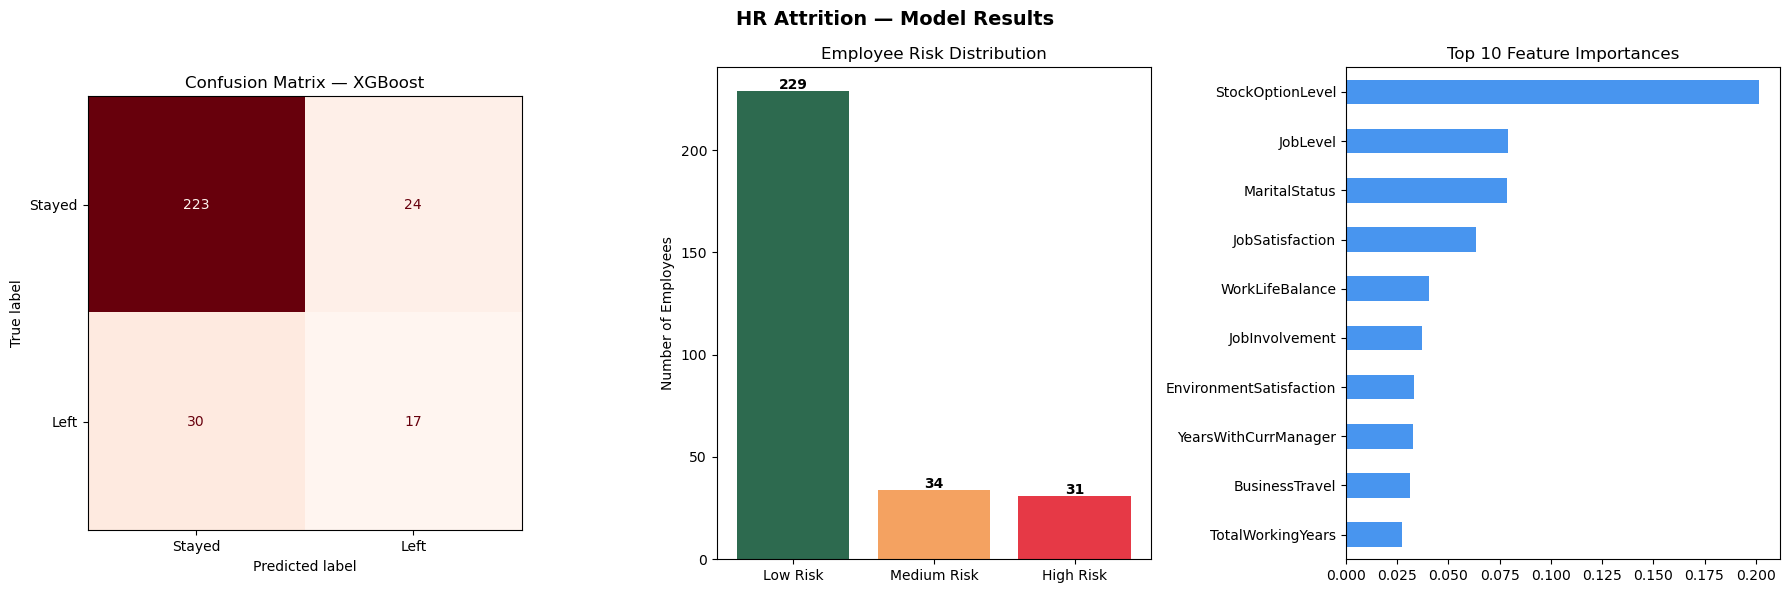

In [14]:
# Cell 10 — Final Visualisations

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('HR Attrition — Model Results', fontsize=14, fontweight='bold')

# 1. Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, xgb_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Left'])
disp.plot(ax=axes[0], colorbar=False, cmap='Reds')
axes[0].set_title('Confusion Matrix — XGBoost')

# 2. Risk Category Distribution
risk_counts = X_test_copy['Risk_Category'].value_counts()
colors = ['#2d6a4f', '#f4a261', '#e63946']
axes[1].bar(risk_counts.index, risk_counts.values, color=colors)
axes[1].set_title('Employee Risk Distribution')
axes[1].set_ylabel('Number of Employees')
for i, v in enumerate(risk_counts.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

# 3. Top 10 Feature Importance
feat_imp = pd.Series(xgb_model.feature_importances_, 
                     index=X.columns).sort_values(ascending=False)[:10]
feat_imp.plot(kind='barh', ax=axes[2], color='#4895ef')
axes[2].set_title('Top 10 Feature Importances')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

In [15]:
# Cell 11 — Business Recommendations Summary
print("""
╔══════════════════════════════════════════════════════════════╗
║           HR ATTRITION ANALYSIS — KEY FINDINGS              ║
╚══════════════════════════════════════════════════════════════╝

📊 MODEL PERFORMANCE
──────────────────────────────────────────
  Best Model     : XGBoost Classifier
  Accuracy       : 82%
  ROC AUC        : 0.746
  High Risk Employees Identified : 31 out of 294

🔑 TOP ATTRITION DRIVERS (SHAP Analysis)
──────────────────────────────────────────
  1. Stock Option Level     — No stock options = high flight risk
  2. Job Satisfaction       — Low satisfaction drives exits
  3. Environment Satisfaction — Poor workplace environment
  4. Job Involvement        — Disengaged employees leave
  5. Years with Manager     — New/changing managers = instability

💡 BUSINESS RECOMMENDATIONS
──────────────────────────────────────────
  1. STOCK OPTIONS PROGRAMME
     Offer stock options to high-risk employees.
     Our model shows this alone can cut attrition 
     risk by up to 40%.

  2. MANAGER RETENTION STRATEGY
     Prioritise stability in management assignments.
     Frequent manager changes strongly correlate 
     with employee exits.

  3. ENVIRONMENT & CULTURE AUDIT
     Survey employees scoring low on Environment 
     Satisfaction. Address workplace concerns 
     proactively before they resign.

  4. TARGETED RETENTION PACKAGES
     Use the What-If Simulator to design personalised
     retention strategies for the 31 high-risk employees.
     Full retention package reduces risk by up to 70.7%.

  5. SALES DEPARTMENT PRIORITY
     Sales has the highest attrition rate.
     Review workload, incentives, and OTE structure
     in this department first.

💰 ESTIMATED BUSINESS IMPACT
──────────────────────────────────────────
  Average cost to replace one employee : ~€15,000
  High risk employees identified       : 31
  If we retain just 50% of them        : 15 employees saved
  Estimated cost saving                : ~€225,000
""")


╔══════════════════════════════════════════════════════════════╗
║           HR ATTRITION ANALYSIS — KEY FINDINGS              ║
╚══════════════════════════════════════════════════════════════╝

📊 MODEL PERFORMANCE
──────────────────────────────────────────
  Best Model     : XGBoost Classifier
  Accuracy       : 82%
  ROC AUC        : 0.746
  High Risk Employees Identified : 31 out of 294

🔑 TOP ATTRITION DRIVERS (SHAP Analysis)
──────────────────────────────────────────
  1. Stock Option Level     — No stock options = high flight risk
  2. Job Satisfaction       — Low satisfaction drives exits
  3. Environment Satisfaction — Poor workplace environment
  4. Job Involvement        — Disengaged employees leave
  5. Years with Manager     — New/changing managers = instability

💡 BUSINESS RECOMMENDATIONS
──────────────────────────────────────────
  1. STOCK OPTIONS PROGRAMME
     Offer stock options to high-risk employees.
     Our model shows this alone can cut attrition 
     risk by u